In [1]:
def start_signature():
    print("="*40)
    print("START OF NOTEBOOK — AT")
    print("="*40)

start_signature()

from sqlalchemy import create_engine
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

START OF NOTEBOOK — AT


In [2]:
#!pip install shap

In [3]:

PG_USER = "postgres"
PG_PASSWORD = "postgre_mimic"
PG_HOST = "127.0.0.1"
PG_PORT = "5433"          
PG_DB = "mimic_raw"

engine = create_engine(
    f"postgresql+psycopg2://{PG_USER}:{PG_PASSWORD}@{PG_HOST}:{PG_PORT}/{PG_DB}"
)

pd.read_sql("SELECT current_database(), current_user;", engine)
pd.read_sql("SELECT version();", engine)

,version
0,"PostgreSQL 18.1 on x86_64-windows, compiled by..."


In [4]:

units = ["Emergency Department", "Emergency Department Observation"]

df_merge2 = pd.read_sql(
    """
    SELECT *
    FROM dm.model_base_by_unit
    WHERE careunit IN ('Emergency Department','Emergency Department Observation')
      AND anchor_age >= 65
      AND unit_los_hours IS NOT NULL
      AND unit_los_hours > 0
    """,
    engine
)

print("Rows pulled (ED, 65+):", df_merge2.shape)
print(df_merge2.head())
df_merge2.info()

Rows pulled (ED, 65+): (171531, 34)
    hadm_id  subject_id                          careunit         unit_intime  \
0  20002699    13799542              Emergency Department 2162-12-07 12:33:00   
1  20006973    18904954              Emergency Department 2174-07-21 15:21:00   
2  20007378    14371353              Emergency Department 2176-06-02 21:27:00   
3  20017834    19581033              Emergency Department 2176-05-05 13:50:00   
4  20017834    19581033  Emergency Department Observation 2176-05-05 19:03:26   

         unit_outtime  unit_los_hours gender  anchor_age           admittime  \
0 2162-12-07 19:17:00            6.73      F          65 2162-12-07 17:36:00   
1 2174-07-21 20:26:00            5.08      F          88 2174-07-21 17:35:00   
2 2176-06-03 00:37:00            3.17      M          72 2176-06-02 23:46:00   
3 2176-05-05 19:03:12            5.22      M          89 2176-05-05 19:01:00   
4 2176-05-05 19:05:22            0.03      M          89 2176-05-05 19:01:00 

In [5]:
# Rename target to match your old ED naming
df_merge2 = df_merge2.rename(columns={"unit_los_hours": "LOS_ED_hours"}).copy()

# ----------------------------
# 3) ADMISSION-LEVEL AGGREGATION (ED + ED Obs summed)
#    - keep earliest entry + latest exit (for anchoring labs)
# ----------------------------
df_merge2["admittime"]   = pd.to_datetime(df_merge2["admittime"], errors="coerce")
df_merge2["unit_intime"] = pd.to_datetime(df_merge2["unit_intime"], errors="coerce")
df_merge2["unit_outtime"]= pd.to_datetime(df_merge2["unit_outtime"], errors="coerce")


In [6]:
if df_merge2["hadm_id"].duplicated().any():
    # build agg dict only from existing columns (safe)
    agg_dict = {
        "LOS_ED_hours": "sum",
        "subject_id": "first",
        "anchor_age": "first",
        "gender": "first",
        "admittime": "first",
        "race": "first",
        "marital_status": "first",
        "insurance": "first",
        "admission_type": "first",
        "admission_location": "first",
        "careunit": "first",
        "unit_intime": "min",
        "unit_outtime": "max",
    }

    
    # include any ICD category columns if present
    icd_like = ["blood","circulatory","congenital","digestive","endocrine","genitourinary",
                "infectious","injury","mental","misc","muscular","neoplasms","nervous",
                "respiratory","skin"]
    for c in icd_like:
        agg_dict[c] = "first"

    # include transfer/past history if present
    for c in ["n_transfers","n_careunits","had_ed_transfer","prev_adm_count","days_since_last_adm"]:
        agg_dict[c] = "first"

    agg_dict = {k:v for k,v in agg_dict.items() if k in df_merge2.columns}

    df_merge2 = (
        df_merge2.sort_values(["hadm_id","unit_intime"])
        .groupby("hadm_id", as_index=False)
        .agg(agg_dict)
    )

df_merge2["LOS_ED_hours"] = df_merge2["LOS_ED_hours"].round(2)
print("✅ After ED admission-level aggregation:", df_merge2.shape)

✅ After ED admission-level aggregation: (147004, 34)


In [7]:
# ----------------------------
# 4) ED TIMING FEATURES (like transplant)
# ----------------------------
df_merge2["admittime"]   = pd.to_datetime(df_merge2["admittime"], errors="coerce")
df_merge2["unit_intime"] = pd.to_datetime(df_merge2["unit_intime"], errors="coerce")
df_merge2["unit_outtime"]= pd.to_datetime(df_merge2["unit_outtime"], errors="coerce")

df_merge2 = df_merge2.dropna(subset=["admittime","unit_intime"]).copy()

df_merge2["hours_to_ed"] = (df_merge2["unit_intime"] - df_merge2["admittime"]).dt.total_seconds()/3600.0
df_merge2["hours_to_ed"] = df_merge2["hours_to_ed"].clip(lower=0)

df_merge2["ed_entry_hour"]  = df_merge2["unit_intime"].dt.hour
df_merge2["ed_entry_day"]   = df_merge2["unit_intime"].dt.dayofweek
df_merge2["ed_entry_month"] = df_merge2["unit_intime"].dt.month

df_merge2["admit_hour"]  = df_merge2["admittime"].dt.hour
df_merge2["admit_day"]   = df_merge2["admittime"].dt.dayofweek
df_merge2["admit_month"] = df_merge2["admittime"].dt.month

print("✅ Timing features created. Shape:", df_merge2.shape)

✅ Timing features created. Shape: (147004, 41)


In [8]:
# ----------------------------
# 5) LAB FEATURES (chunk in Python)
#     - pull dm.dim_labitems
#     - stream labevents.csv.gz (same as transplant)
# ----------------------------
df_labitems = pd.read_sql("""SELECT itemid, label FROM dm.dim_labitems;""", engine)

ED_LABS = {
    # typical ED + triage/basic labs (edit any time)
    "Sodium","Potassium","Chloride","Bicarbonate",
    "Creatinine","Urea Nitrogen","Glucose",
    "White Blood Cells","Hemoglobin","Platelet Count",
    "Lactate","Troponin T","Troponin I",
    "INR(PT)","PT","PTT"
}

ed_labitems = df_labitems[df_labitems["label"].isin(ED_LABS)].copy()
ed_lab_itemids = set(ed_labitems["itemid"].unique())

print("Selected ED lab labels found:")
print(ed_labitems["label"].value_counts())
print("ItemIDs to keep:", ed_lab_itemids)

Selected ED lab labels found:
label
Glucose              5
Hemoglobin           3
Lactate              3
Potassium            3
White Blood Cells    3
Chloride             2
Sodium               2
Creatinine           2
PT                   2
Troponin I           2
INR(PT)              2
Urea Nitrogen        2
PTT                  2
Platelet Count       2
Bicarbonate          1
Troponin T           1
Name: count, dtype: int64
ItemIDs to keep: {np.int64(52610), np.int64(51981), np.int64(52623), np.int64(50833), np.int64(51222), np.int64(51478), np.int64(50971), np.int64(52642), np.int64(53154), np.int64(51237), np.int64(50983), np.int64(52647), np.int64(51755), np.int64(51756), np.int64(52535), np.int64(51640), np.int64(52921), np.int64(51002), np.int64(51003), np.int64(52923), np.int64(51006), np.int64(51265), np.int64(50882), np.int64(52546), np.int64(53189), np.int64(51274), np.int64(51275), np.int64(50902), np.int64(52569), np.int64(52442), np.int64(51675), np.int64(50912), np.int64

In [9]:

ed_hadm_ids = set(df_merge2["hadm_id"].dropna().unique())
print("ED admissions used for labs:", len(ed_hadm_ids))


ED admissions used for labs: 147004


In [10]:
ed_hadm_ids = set(df_merge2["hadm_id"].dropna().unique())
print("ED admissions used for labs:", len(ed_hadm_ids))

ed_entry_map = (
    df_merge2[["hadm_id", "unit_intime"]]
    .dropna()
    .set_index("hadm_id")["unit_intime"]
    .to_dict()
)

adm_time_map = (
    df_merge2[["hadm_id", "admittime"]]
    .dropna()
    .set_index("hadm_id")["admittime"]
    .to_dict()
)

ED admissions used for labs: 147004


In [11]:


import time
from collections import defaultdict

LABEVENTS_PATH = r"C:\Users\arpitha_work\Downloads\TRU MSCDS\Sem 3\Graduate Project\MIMIC\mimic-iv-3.1\hosp\labevents.csv.gz"

EARLY_WINDOW_HOURS = 6   # ED: usually tighter than transplant; change to 12 if you want
CHUNKSIZE = 50_000

t0 = time.time()
chunk_counter = 0
rows_kept_total = 0

sum_dict   = defaultdict(float)
count_dict = defaultdict(int)
min_dict   = defaultdict(lambda: np.inf)
max_dict   = defaultdict(lambda: -np.inf)

for chunk in pd.read_csv(
    LABEVENTS_PATH,
    compression="gzip",
    usecols=["hadm_id", "itemid", "charttime", "valuenum"],
    chunksize=CHUNKSIZE
):
    chunk_counter += 1
    chunk = chunk[
        chunk["hadm_id"].isin(ed_hadm_ids) &
        chunk["itemid"].isin(ed_lab_itemids)
    ].dropna(subset=["charttime", "valuenum"])

    if chunk.empty:
        if chunk_counter % 50 == 0:
            print(f"chunks={chunk_counter}, kept_rows={rows_kept_total}, elapsed={(time.time()-t0)/60:.1f} min")
        continue

    chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")
    chunk = chunk.dropna(subset=["charttime", "valuenum"])

    chunk["anchor_time"] = chunk["hadm_id"].map(ed_entry_map)
    chunk["anchor_time"] = chunk["anchor_time"].fillna(chunk["hadm_id"].map(adm_time_map))
    chunk = chunk.dropna(subset=["anchor_time"])

    hours_from_anchor = (chunk["charttime"] - chunk["anchor_time"]).dt.total_seconds() / 3600.0
    chunk = chunk[(hours_from_anchor >= 0) & (hours_from_anchor <= EARLY_WINDOW_HOURS)]

    if chunk.empty:
        if chunk_counter % 50 == 0:
            print(f"chunks={chunk_counter}, kept_rows={rows_kept_total}, elapsed={(time.time()-t0)/60:.1f} min")
        continue

    rows_kept_total += len(chunk)
    g = chunk.groupby(["hadm_id", "itemid"])["valuenum"]
    s = g.sum()
    c = g.count()
    mn = g.min()
    mx = g.max()

    for k, v in s.items():
        sum_dict[k] += float(v)
    for k, v in c.items():
        count_dict[k] += int(v)
    for k, v in mn.items():
        min_dict[k] = min(min_dict[k], float(v))
    for k, v in mx.items():
        max_dict[k] = max(max_dict[k], float(v))

    if chunk_counter % 50 == 0:
        print(f"chunks={chunk_counter}, kept_rows={rows_kept_total}, elapsed={(time.time()-t0)/60:.1f} min")











print("Finished streaming labevents")
print("Total chunks:", chunk_counter)
print("Rows kept:", rows_kept_total)
print("Total minutes:", (time.time() - t0) / 60)

chunks=50, kept_rows=6481, elapsed=0.4 min
chunks=100, kept_rows=12489, elapsed=0.8 min
chunks=150, kept_rows=18872, elapsed=1.3 min
chunks=200, kept_rows=24610, elapsed=1.7 min
chunks=250, kept_rows=31367, elapsed=2.1 min
chunks=300, kept_rows=37564, elapsed=2.5 min


C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_43836\2179103723.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")


chunks=350, kept_rows=44265, elapsed=2.9 min
chunks=400, kept_rows=50786, elapsed=3.3 min
chunks=450, kept_rows=56485, elapsed=3.6 min
chunks=500, kept_rows=62758, elapsed=3.9 min
chunks=550, kept_rows=68860, elapsed=4.2 min
chunks=600, kept_rows=74868, elapsed=4.5 min
chunks=650, kept_rows=81055, elapsed=4.8 min
chunks=700, kept_rows=87024, elapsed=5.1 min
chunks=750, kept_rows=93796, elapsed=5.4 min
chunks=800, kept_rows=99469, elapsed=5.7 min
chunks=850, kept_rows=105643, elapsed=6.0 min
chunks=900, kept_rows=111433, elapsed=6.3 min
chunks=950, kept_rows=117635, elapsed=6.7 min
chunks=1000, kept_rows=123552, elapsed=7.0 min
chunks=1050, kept_rows=129702, elapsed=7.3 min
chunks=1100, kept_rows=135801, elapsed=7.7 min
chunks=1150, kept_rows=142646, elapsed=8.0 min
chunks=1200, kept_rows=148390, elapsed=8.4 min
chunks=1250, kept_rows=154172, elapsed=8.8 min
chunks=1300, kept_rows=160135, elapsed=9.1 min
chunks=1350, kept_rows=166403, elapsed=9.5 min
chunks=1400, kept_rows=172542, elaps

C:\Users\arpitha_work\AppData\Local\Temp\ipykernel_43836\2179103723.py:35: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk["charttime"] = pd.to_datetime(chunk["charttime"], errors="coerce")


chunks=2350, kept_rows=288971, elapsed=15.9 min
chunks=2400, kept_rows=294693, elapsed=16.2 min
chunks=2450, kept_rows=300546, elapsed=16.5 min
chunks=2500, kept_rows=306305, elapsed=16.8 min
chunks=2550, kept_rows=312720, elapsed=17.1 min
chunks=2600, kept_rows=318532, elapsed=17.4 min
chunks=2650, kept_rows=324110, elapsed=17.7 min
chunks=2700, kept_rows=330295, elapsed=18.0 min
chunks=2750, kept_rows=336179, elapsed=18.4 min
chunks=2800, kept_rows=342467, elapsed=18.7 min
chunks=2850, kept_rows=348503, elapsed=19.0 min
chunks=2900, kept_rows=354700, elapsed=19.3 min
chunks=2950, kept_rows=360926, elapsed=19.6 min
chunks=3000, kept_rows=367556, elapsed=19.9 min
chunks=3050, kept_rows=373558, elapsed=20.2 min
chunks=3100, kept_rows=379941, elapsed=20.5 min
chunks=3150, kept_rows=385558, elapsed=20.8 min
Finished streaming labevents
Total chunks: 3168
Rows kept: 387658
Total minutes: 20.950834035873413


In [12]:
rows = []
for (hadm_id, itemid), cnt in count_dict.items():
    rows.append({
        "hadm_id": hadm_id,
        "itemid": itemid,
        "lab_mean": sum_dict[(hadm_id, itemid)] / cnt,
        "lab_min":  min_dict[(hadm_id, itemid)],
        "lab_max":  max_dict[(hadm_id, itemid)],
        "lab_count": cnt
    })

lab_agg = pd.DataFrame(rows).merge(df_labitems, on="itemid", how="left")

lab_agg["lab_sum"] = lab_agg["lab_mean"] * lab_agg["lab_count"]

In [13]:
lab_collapsed = (
    lab_agg
    .groupby(["hadm_id", "label"], as_index=False)
    .agg(
        lab_sum=("lab_sum", "sum"),
        lab_count=("lab_count", "sum"),
        lab_min=("lab_min", "min"),
        lab_max=("lab_max", "max")
    )
)
lab_collapsed["lab_mean"] = lab_collapsed["lab_sum"] / lab_collapsed["lab_count"]

lab_wide = lab_collapsed.pivot_table(
    index="hadm_id",
    columns="label",
    values=["lab_mean","lab_min","lab_max","lab_count"],
    aggfunc="first"
)
lab_wide.columns = [f"{stat}_{label}".replace(" ", "_") for stat, label in lab_wide.columns]
lab_wide = lab_wide.reset_index()

df_merge2 = df_merge2.merge(lab_wide, on="hadm_id", how="left")
print("✅ df_merge2 shape after merging labs:", df_merge2.shape)

✅ df_merge2 shape after merging labs: (147004, 101)


In [14]:
# 6) LAB FLAGS + DERIVED RATIOS (same pattern)
# ----------------------------
lab_count_cols = [c for c in df_merge2.columns if c.startswith("lab_count_")]
for c in lab_count_cols:
    df_merge2[c + "_measured_flag"] = (df_merge2[c].fillna(0) > 0).astype(int)

def safe_div(a, b):
    return np.where((b == 0) | pd.isna(b), np.nan, a / b)

if "lab_mean_Creatinine" in df_merge2.columns and "lab_mean_Urea_Nitrogen" in df_merge2.columns:
    df_merge2["bun_creatinine_ratio"] = safe_div(df_merge2["lab_mean_Urea_Nitrogen"], df_merge2["lab_mean_Creatinine"])

if "lab_mean_INR(PT)" in df_merge2.columns:
    df_merge2["inr_high_flag"] = (df_merge2["lab_mean_INR(PT)"] >= 1.5).astype(int)

if "lab_mean_Sodium" in df_merge2.columns:
    df_merge2["sodium_low_flag"]  = (df_merge2["lab_mean_Sodium"] < 135).astype(int)
    df_merge2["sodium_high_flag"] = (df_merge2["lab_mean_Sodium"] > 145).astype(int)

if "lab_mean_Glucose" in df_merge2.columns:
    df_merge2["glucose_high_flag"] = (df_merge2["lab_mean_Glucose"] >= 180).astype(int)

print("✅ Added lab flags/ratios")

✅ Added lab flags/ratios


In [15]:
# =====================================
# SAVE DATASET FOR EDA -feature level eda - before modeling
# =====================================

#df_merge2.to_csv("ed_dataset_for_eda.csv", index=False)
df_merge2.to_parquet("ed_dataset_for_eda.parquet", index=False)

print("Dataset saved for EDA:", df_merge2.shape)

Dataset saved for EDA: (147004, 121)


In [16]:
# pip install pyarrow

In [17]:
""" 
7) TARGET BINNING → los_class (classification like neurology)
 ----------------------------
TARGET_COL = "LOS_ED_hours"
df_merge2 = df_merge2[df_merge2[TARGET_COL].notna()].copy()
df_merge2 = df_merge2[df_merge2[TARGET_COL] > 0].copy()

# Use quantile-based bins (same style as transplant)
q1, q2 = df_merge2[TARGET_COL].quantile([0.33, 0.66])
bins = [0, q1, q2, np.inf]
labels = [0, 1, 2]

df_merge2["los_class"] = pd.cut(df_merge2[TARGET_COL], bins=bins, labels=labels, right=False)
df_merge2 = df_merge2[df_merge2["los_class"].notna()].copy()
df_merge2["los_class"] = df_merge2["los_class"].astype(int)

print("Bins used:", bins)
print(df_merge2["los_class"].value_counts(normalize=True).sort_index())"""

' \n7) TARGET BINNING → los_class (classification like neurology)\n ----------------------------\nTARGET_COL = "LOS_ED_hours"\ndf_merge2 = df_merge2[df_merge2[TARGET_COL].notna()].copy()\ndf_merge2 = df_merge2[df_merge2[TARGET_COL] > 0].copy()\n\n# Use quantile-based bins (same style as transplant)\nq1, q2 = df_merge2[TARGET_COL].quantile([0.33, 0.66])\nbins = [0, q1, q2, np.inf]\nlabels = [0, 1, 2]\n\ndf_merge2["los_class"] = pd.cut(df_merge2[TARGET_COL], bins=bins, labels=labels, right=False)\ndf_merge2 = df_merge2[df_merge2["los_class"].notna()].copy()\ndf_merge2["los_class"] = df_merge2["los_class"].astype(int)\n\nprint("Bins used:", bins)\nprint(df_merge2["los_class"].value_counts(normalize=True).sort_index())'

In [18]:
# ----------------------------
# 7) TARGET BINNING (QUANTILE-BASED) → los_class
# ----------------------------
TARGET_COL = "LOS_ED_hours"
df_merge2 = df_merge2[df_merge2[TARGET_COL].notna()].copy()
df_merge2 = df_merge2[df_merge2[TARGET_COL] > 0].copy()

# Compute tertile boundaries from data
q33 = df_merge2[TARGET_COL].quantile(0.33)
q66 = df_merge2[TARGET_COL].quantile(0.66)

bins = [0, q33, q66, np.inf]
labels = [0, 1, 2]

df_merge2["los_class"] = pd.cut(
    df_merge2[TARGET_COL],
    bins=bins,
    labels=labels,
    right=True
)

df_merge2 = df_merge2[df_merge2["los_class"].notna()].copy()
df_merge2["los_class"] = df_merge2["los_class"].astype(int)

print(f"Tertile boundaries: q33={q33:.2f}h, q66={q66:.2f}h")
print(f"Bins used (hours): [0, {q33:.2f}, {q66:.2f}, inf]")
print("\nClass distribution:")
print(df_merge2["los_class"].value_counts().sort_index())
print("\nProportions:")
print(df_merge2["los_class"].value_counts(normalize=True).sort_index())

Tertile boundaries: q33=5.14h, q66=8.50h
Bins used (hours): [0, 5.14, 8.50, inf]

Class distribution:
los_class
0    48532
1    48540
2    49932
Name: count, dtype: int64

Proportions:
los_class
0    0.330141
1    0.330195
2    0.339664
Name: proportion, dtype: float64


In [19]:
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


def build_ed_model_inputs(
    df: pd.DataFrame,
    target_col: str = "LOS_ED_hours",
    class_col: str = "los_class",
    group_col: str = "subject_id",
    drop_cols: list | None = None,
    datetime_mode: str = "parts",  # "parts" (recommended) or "drop"
):
    """
    ED preprocessing for your df_merge2 (post-aggregation + lab features).
    Returns:
      X: feature dataframe (raw, not transformed)
      y: target labels
      groups: grouping for GroupShuffleSplit/GroupKFold (subject_id)
    """

    df = df.copy()

    # --- safety: keep only rows with valid target/class ---
    if class_col in df.columns:
        df = df[df[class_col].notna()].copy()

    if target_col in df.columns:
        df = df[df[target_col].notna()].copy()

    # --- default columns to drop (IDs + known leakage-ish columns) ---
    default_drop = ["hadm_id", "subject_id", "unit_outtime"]
    if drop_cols is not None:
        default_drop = list(dict.fromkeys(default_drop + drop_cols))  # merge + dedupe

    # y, groups
    if class_col not in df.columns:
        raise ValueError(f"Expected '{class_col}' in dataframe. Create los_class first.")
    y = df[class_col].astype(int)

    if group_col not in df.columns:
        raise ValueError(f"Expected '{group_col}' in dataframe for group split.")
    groups = df[group_col]

    # X
    X = df.drop(columns=[c for c in [target_col, class_col] if c in df.columns], errors="ignore")
    X = X.drop(columns=[c for c in default_drop if c in X.columns], errors="ignore")

    # --- datetime handling ---
    dt_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
    if dt_cols and datetime_mode == "parts":
        for col in dt_cols:
            dt = pd.to_datetime(X[col], errors="coerce")
            X[col + "_hour"] = dt.dt.hour
            X[col + "_weekday"] = dt.dt.weekday
            X[col + "_month"] = dt.dt.month
        X.drop(columns=dt_cols, inplace=True, errors="ignore")
    elif dt_cols and datetime_mode == "drop":
        X.drop(columns=dt_cols, inplace=True, errors="ignore")

    # --- categorical cleanup (exactly like your current code) ---
    cat_cols = X.select_dtypes(include=["object", "string", "category"]).columns.tolist()
    if cat_cols:
        X[cat_cols] = X[cat_cols].astype(str)
        X[cat_cols] = X[cat_cols].replace({"nan": np.nan, "NaT": np.nan, "None": np.nan})

    return X, y, groups


def build_preprocess_transformer(X_train: pd.DataFrame):
    """
    Builds a ColumnTransformer using columns detected from X_train.
    Returns preprocess transformer + (num_cols, cat_cols) for reference.
    """
    num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
    cat_cols = [c for c in X_train.columns if c not in num_cols]

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ])

    preprocess = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, num_cols),
            ("cat", categorical_transformer, cat_cols),
        ],
        remainder="drop",
        sparse_threshold=0.0
    )

    return preprocess, num_cols, cat_cols

In [20]:
TARGET_COL = "LOS_ED_hours"

In [21]:
# ----------------------------
# 8) MODELING — CLASSIFICATION (same as neurology/transplant)
# ----------------------------
from sklearn.model_selection import GroupShuffleSplit
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import StackingClassifier
import copy
import warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix,
    balanced_accuracy_score, roc_auc_score, roc_curve, auc,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize

import shap

from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, balanced_accuracy_score

# leakage safety: drop future times
df_merge2 = df_merge2.drop(columns=[c for c in ["unit_outtime"] if c in df_merge2.columns], errors="ignore")

""""
#X, y, groups = build_ed_model_inputs(df_merge2)
X = df_merge2.drop(columns=[TARGET_COL, "los_class", "hadm_id", "subject_id"], errors="ignore").copy()
y = df_merge2["los_class"].astype(int).copy()"""


'"\n#X, y, groups = build_ed_model_inputs(df_merge2)\nX = df_merge2.drop(columns=[TARGET_COL, "los_class", "hadm_id", "subject_id"], errors="ignore").copy()\ny = df_merge2["los_class"].astype(int).copy()'

In [22]:
"""# datetime -> parts
datetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()
for col in datetime_cols:
    dt = pd.to_datetime(X[col], errors="coerce")
    X[col + "_hour"] = dt.dt.hour
    X[col + "_weekday"] = dt.dt.weekday
    X[col + "_month"] = dt.dt.month
X.drop(columns=datetime_cols, inplace=True, errors="ignore")

cat_like = X.select_dtypes(include=["object", "string", "category"]).columns
X[cat_like] = X[cat_like].astype(str)
X[cat_like] = X[cat_like].replace({"nan": np.nan, "NaT": np.nan, "None": np.nan})"""



'# datetime -> parts\ndatetime_cols = X.select_dtypes(include=["datetime64[ns]", "datetime64[ns, UTC]"]).columns.tolist()\nfor col in datetime_cols:\n    dt = pd.to_datetime(X[col], errors="coerce")\n    X[col + "_hour"] = dt.dt.hour\n    X[col + "_weekday"] = dt.dt.weekday\n    X[col + "_month"] = dt.dt.month\nX.drop(columns=datetime_cols, inplace=True, errors="ignore")\n\ncat_like = X.select_dtypes(include=["object", "string", "category"]).columns\nX[cat_like] = X[cat_like].astype(str)\nX[cat_like] = X[cat_like].replace({"nan": np.nan, "NaT": np.nan, "None": np.nan})'

In [23]:


X, y, groups = build_ed_model_inputs(
    df_merge2,
    target_col="LOS_ED_hours",
    class_col="los_class",
    group_col="subject_id",
    drop_cols=None,           # add extra columns here if needed
    datetime_mode="parts"
)

from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()

preprocess, num_cols, cat_cols = build_preprocess_transformer(X_train)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)
print("Numeric cols:", len(num_cols), "Categorical cols:", len(cat_cols))

Train shape: (117834, 121) Test shape: (29170, 121)
Numeric cols: 114 Categorical cols: 7


In [24]:
""" Group split by subject_id (same as neuro)
groups = df_merge2["subject_id"]
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()
y_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()"""

' Group split by subject_id (same as neuro)\ngroups = df_merge2["subject_id"]\ngss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)\ntrain_idx, test_idx = next(gss.split(X, y, groups=groups))\nX_train, X_test = X.iloc[train_idx].copy(), X.iloc[test_idx].copy()\ny_train, y_test = y.iloc[train_idx].copy(), y.iloc[test_idx].copy()'

In [25]:
"""num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols),
    ],
    remainder="drop",
    sparse_threshold=0.0
)"""

'num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()\ncat_cols = [c for c in X_train.columns if c not in num_cols]\n\nnumeric_transformer = Pipeline(steps=[\n    ("imputer", SimpleImputer(strategy="median")),\n    ("scaler", StandardScaler())\n])\n\ncategorical_transformer = Pipeline(steps=[\n    ("imputer", SimpleImputer(strategy="most_frequent")),\n    ("onehot", OneHotEncoder(handle_unknown="ignore"))\n])\n\npreprocess = ColumnTransformer(\n    transformers=[\n        ("num", numeric_transformer, num_cols),\n        ("cat", categorical_transformer, cat_cols),\n    ],\n    remainder="drop",\n    sparse_threshold=0.0\n)'

In [26]:

rf = RandomForestClassifier(
    n_estimators=200, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1) # class_weight="balanced"


et = ExtraTreesClassifier(
    n_estimators=300, max_depth=12, min_samples_leaf=5,
    random_state=42, n_jobs=-1) #class_weight="balanced"


gbr = GradientBoostingClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42
)

logreg = LogisticRegression(max_iter=2000) #class_weight="balanced

voting_soft = VotingClassifier(
    estimators=[("lr", logreg), ("rf", rf), ("et", et),("gbr" , gbr)],
    voting="soft"
)

stack_model = StackingClassifier(
    estimators=[
       # ("lr", logreg),
        ("rf", rf),
        ("et", et)
    ],
    final_estimator=LogisticRegression(max_iter=2000),
    cv=3,
   # passthrough=False,
    #n_jobs=None
)

models = {
    "LogisticRegression": logreg,
    "RandomForest": rf,
    "ExtraTrees": et,
    "GradientBoostingClassifier": gbr,
    "VotingSoft": voting_soft,
    "Stacking":stack_model
}

In [27]:
#smote = SMOTE(random_state=42, k_neighbors=3)
results = {}
pred_store = {}
trained_pipes = {}

import copy

for name, model in models.items():
    preprocess_fresh, _, _ = build_preprocess_transformer(X_train)  # fresh each time
    
    pipe = ImbPipeline(steps=[
        ("preprocess", preprocess_fresh),
        #("smote", SMOTE(random_state=42, k_neighbors=3)),  # fresh SMOTE too
        ("model", copy.deepcopy(model))
    ])

    print(f"\nTraining: {name}")

    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)

    y_proba = pipe.predict_proba(X_test)

    roc_auc_macro = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="macro"
    )

    roc_auc_weighted = roc_auc_score(
    y_test,
    y_proba,
    multi_class="ovr",
    average="weighted"
    )

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced_Acc": balanced_accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "ROC_AUC_macro": roc_auc_macro,
        "ROC_AUC_weighted": roc_auc_weighted
    }
    trained_pipes[name] = pipe
    pred_store[name] = {
    "y_pred": y_pred,
    "y_proba": y_proba
}

    print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))



Training: LogisticRegression
Confusion matrix:
 [[5326 2688 1701]
 [3206 3622 2752]
 [1229 1775 6871]]
              precision    recall  f1-score   support

           0       0.55      0.55      0.55      9715
           1       0.45      0.38      0.41      9580
           2       0.61      0.70      0.65      9875

    accuracy                           0.54     29170
   macro avg       0.53      0.54      0.54     29170
weighted avg       0.53      0.54      0.54     29170


Training: RandomForest
Confusion matrix:
 [[6493 2372  850]
 [1886 5847 1847]
 [ 599 1689 7587]]
              precision    recall  f1-score   support

           0       0.72      0.67      0.69      9715
           1       0.59      0.61      0.60      9580
           2       0.74      0.77      0.75      9875

    accuracy                           0.68     29170
   macro avg       0.68      0.68      0.68     29170
weighted avg       0.68      0.68      0.68     29170


Training: ExtraTrees
Confusion matr

KeyboardInterrupt: 

In [ ]:

results_df = pd.DataFrame(results).T.sort_values("F1_macro", ascending=False)
print("\n===== RESULTS (sorted by F1_macro) =====")
print(results_df)


===== RESULTS (sorted by F1_macro) =====
                            Accuracy  Balanced_Acc  F1_macro  F1_weighted  \
GradientBoostingClassifier  0.786390      0.786079  0.785849     0.786290   
VotingSoft                  0.734590      0.733852  0.733219     0.733777   
Stacking                    0.683956      0.683654  0.686021     0.686702   
RandomForest                0.683133      0.682329  0.682492     0.683259   
ExtraTrees                  0.634213      0.632856  0.629418     0.630367   
LogisticRegression          0.542304      0.540700  0.535081     0.536281   

                            ROC_AUC_macro  ROC_AUC_weighted  
GradientBoostingClassifier       0.921507          0.921814  
VotingSoft                       0.879540          0.879849  
Stacking                         0.851834          0.852349  
RandomForest                     0.840507          0.841036  
ExtraTrees                       0.793979          0.794631  
LogisticRegression               0.730441     

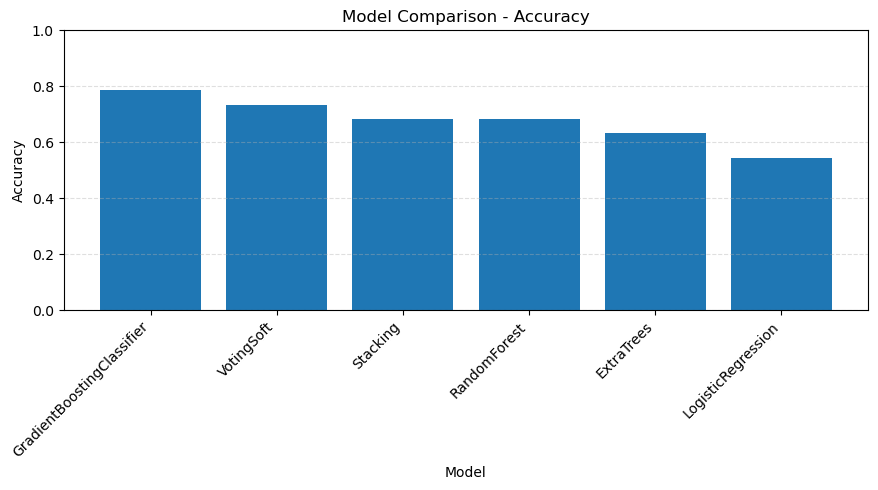

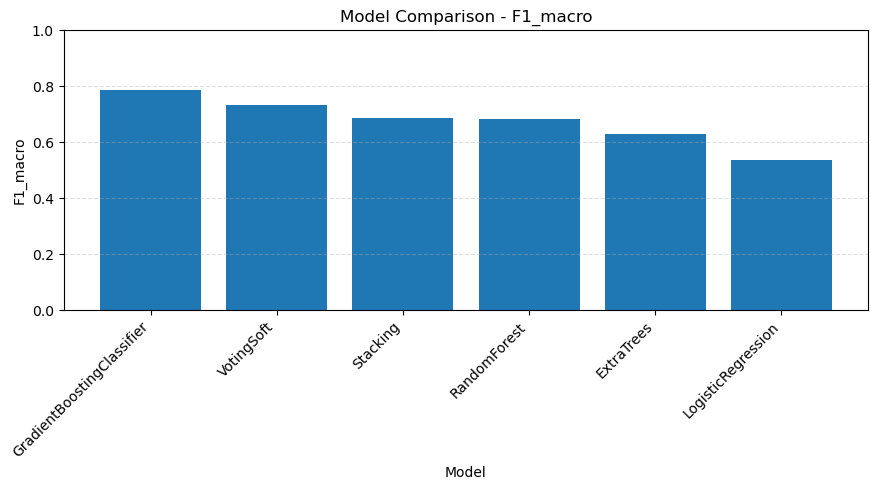

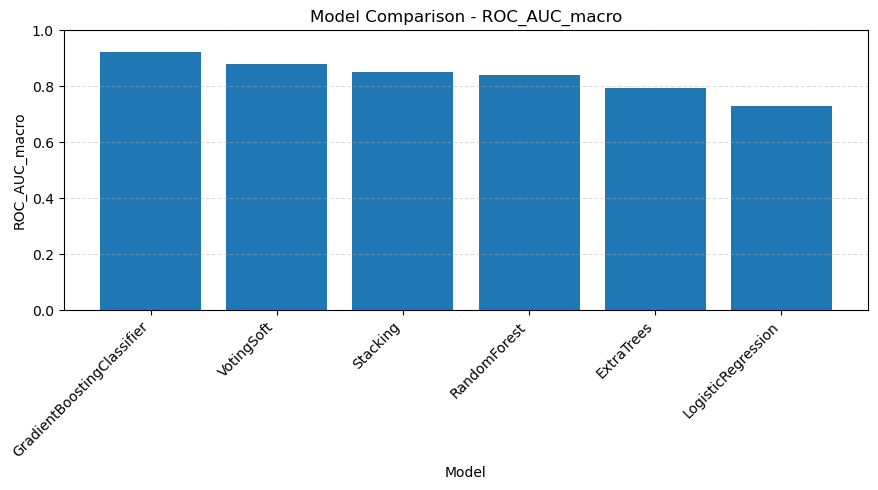

In [ ]:
# ============================
# METRIC BAR PLOTS
# ============================

metric_cols = ["Accuracy", "F1_macro", "ROC_AUC_macro"]

for metric in metric_cols:
    plt.figure(figsize=(9, 5))
    plot_df = results_df.sort_values(metric, ascending=False)

    plt.bar(plot_df.index, plot_df[metric])
    plt.title(f"Model Comparison - {metric}")
    plt.ylabel(metric)
    plt.xlabel("Model")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 1)   # metrics are between 0 and 1
    plt.grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

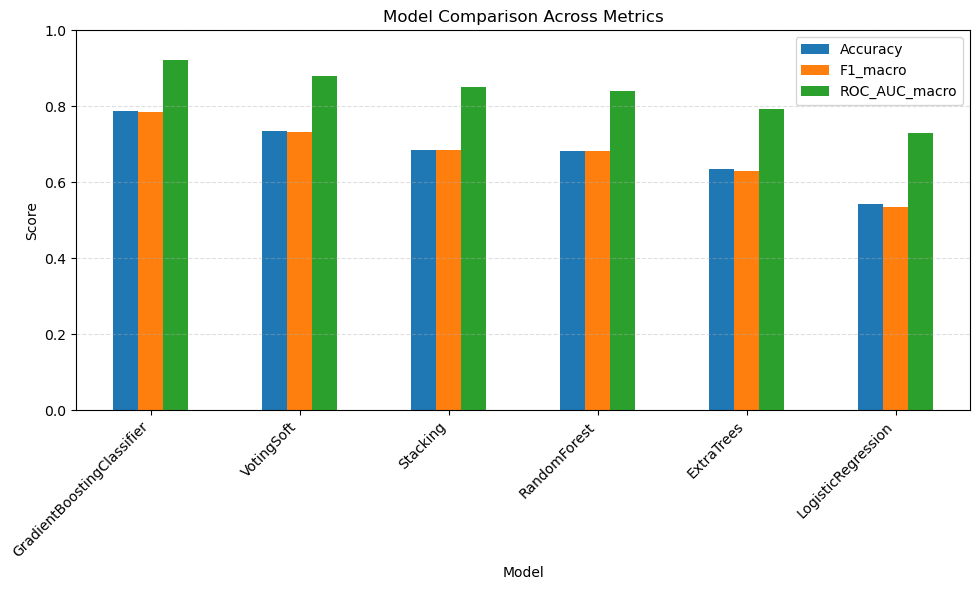

In [ ]:
# ============================
# COMBINED METRIC PLOT
# ============================

plot_metrics = ["Accuracy", "F1_macro", "ROC_AUC_macro"]

plot_df = results_df[plot_metrics].copy()

ax = plot_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Comparison Across Metrics")
plt.ylabel("Score")
plt.xlabel("Model")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

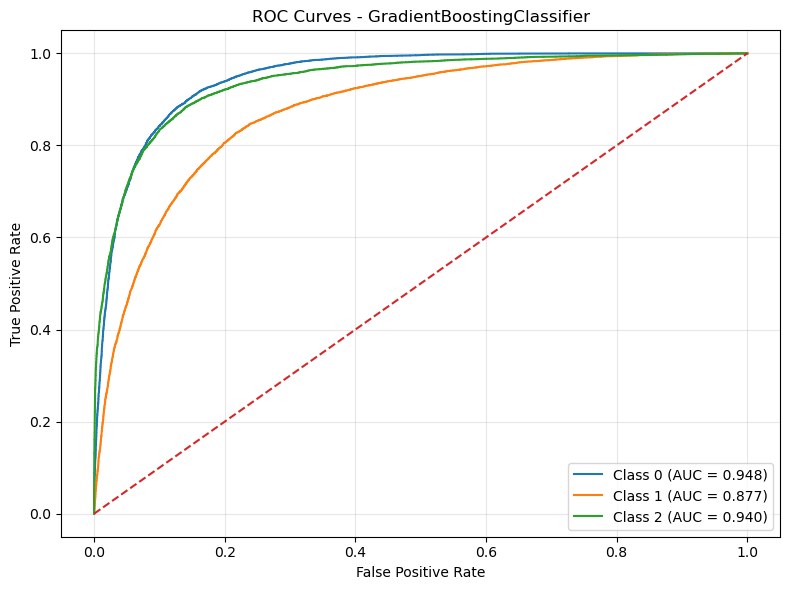

In [ ]:
classes = np.sort(y_test.unique())

from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

# ============================
# ROC CURVES - BEST MODEL
# ============================

best_model_name = "GradientBoostingClassifier"
best_y_proba = pred_store[best_model_name]["y_proba"]

y_test_bin = label_binarize(y_test, classes=classes)

plt.figure(figsize=(8, 6))

for i, cls in enumerate(classes):
    if len(np.unique(y_test_bin[:, i])) < 2:
        print(f"Skipping ROC for class {cls} because only one label present in y_test.")
        continue

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], best_y_proba[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"ROC Curves - {best_model_name}")
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
# ============================
# CROSS-VALIDATION — GBM (GroupKFold, 5 splits)
# ============================
from sklearn.model_selection import cross_val_score, GroupKFold
from sklearn.pipeline import Pipeline as SklearnPipeline

gkf = GroupKFold(n_splits=5)

preprocess_cv, _, _ = build_preprocess_transformer(X_train)

pipe_cv = SklearnPipeline(steps=[
    ("preprocess", preprocess_cv),
    ("model", GradientBoostingClassifier(
        n_estimators=100, learning_rate=0.05, max_depth=3, random_state=42
    ))
])

cv_scores = cross_val_score(
    pipe_cv,
    X, y,
    cv=gkf.split(X, y, groups=groups),
    scoring="f1_macro",
    n_jobs=-1,
    verbose=1
)

print("GBM CV F1_macro per fold:", np.round(cv_scores, 4))
print(f"Mean: {cv_scores.mean():.4f}  ±  Std: {cv_scores.std():.4f}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of   5 | elapsed: 10.8min finished


GBM CV F1_macro per fold: [0.7291 0.7254 0.7137 0.7235 0.7208]
Mean: 0.7225  ±  Std: 0.0052


In [35]:
# ============================
# SHAP — GradientBoostingClassifier
# ============================
import shap

best_model_name = "GradientBoostingClassifier"
best_pipe = trained_pipes[best_model_name]

# ── Step 1: Extract the trained GBM model from inside the pipeline
gbm_model = best_pipe.named_steps["model"]

# ── Step 2: Transform X_train and X_test using the fitted preprocessor
# We need the transformed arrays because SHAP works on what the model actually saw
X_train_transformed = best_pipe.named_steps["preprocess"].transform(X_train)
X_test_transformed  = best_pipe.named_steps["preprocess"].transform(X_test)

# ── Step 3: Get feature names after preprocessing
# num__ prefix = numeric features, cat__ prefix = one-hot encoded categories
feature_names = best_pipe.named_steps["preprocess"].get_feature_names_out()

# Convert to DataFrames so SHAP plots show feature names not column indices
X_train_transformed_df = pd.DataFrame(
    X_train_transformed,
    columns=feature_names
)
X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=feature_names
)

# ── Step 4: Sample for speed — SHAP on full dataset is slow
background_size = min(200, len(X_train_transformed_df))
explain_size    = min(150, len(X_test_transformed_df))

X_background = X_train_transformed_df.sample(background_size, random_state=42)
X_explain    = X_test_transformed_df.sample(explain_size, random_state=42)

# ── Step 5: Compute SHAP values using TreeExplainer
# TreeExplainer is the right choice for GBM — fast and exact
# REPLACE WITH THIS
explainer = shap.Explainer(
    gbm_model.predict_proba,
    X_background
)
shap_values_obj = explainer(X_explain)
shap_arr = shap_values_obj.values
shap_values = [shap_arr[:, :, i] for i in range(shap_arr.shape[2])]

# shap_values is a list of 3 arrays — one per class (0, 1, 2)
# each array shape: (n_samples, n_features)
print("SHAP computed ✓")
print("X_explain shape:", X_explain.shape)
print("Number of class arrays:", len(shap_values))




PermutationExplainer explainer: 151it [00:37,  3.55it/s]                         

SHAP computed ✓
X_explain shape: (150, 180)
Number of class arrays: 3



SHAP Global Bar Plot — Class 0


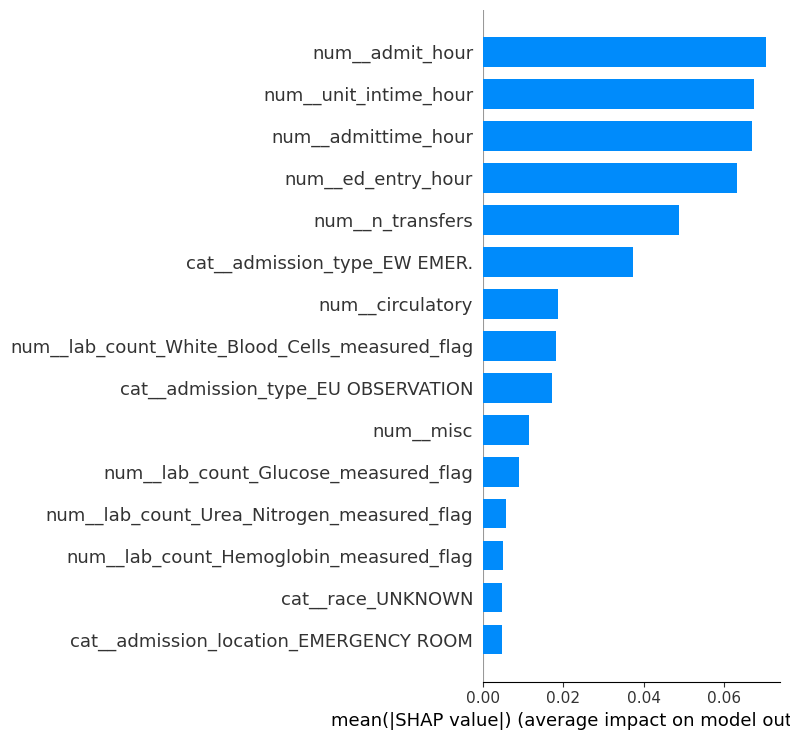


SHAP Global Bar Plot — Class 1


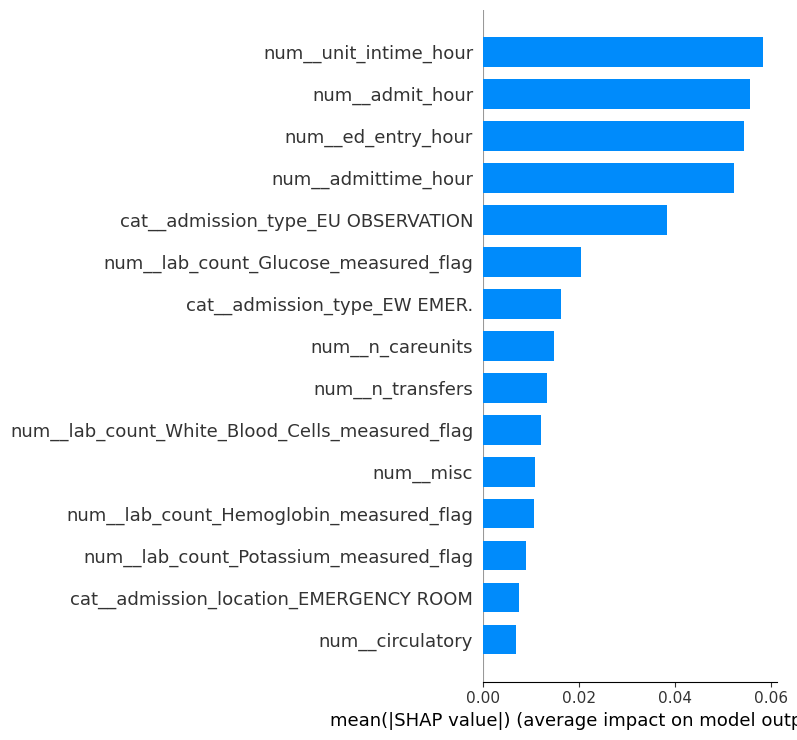


SHAP Global Bar Plot — Class 2


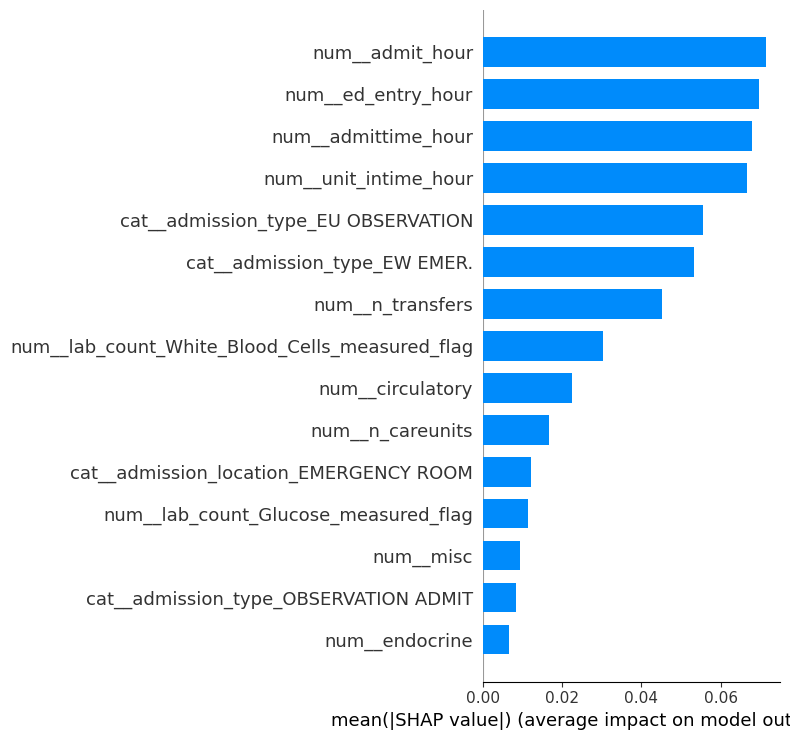

In [36]:
# ── Step 6: Global Bar Plot — top features per class
for class_idx in range(len(shap_values)):
    print(f"\nSHAP Global Bar Plot — Class {class_idx}")
    shap.summary_plot(
        shap_values[class_idx],
        X_explain,
        plot_type="bar",
        max_display=15,   # show top 15 features only
        show=True
    )





SHAP Beeswarm Plot — Class 0


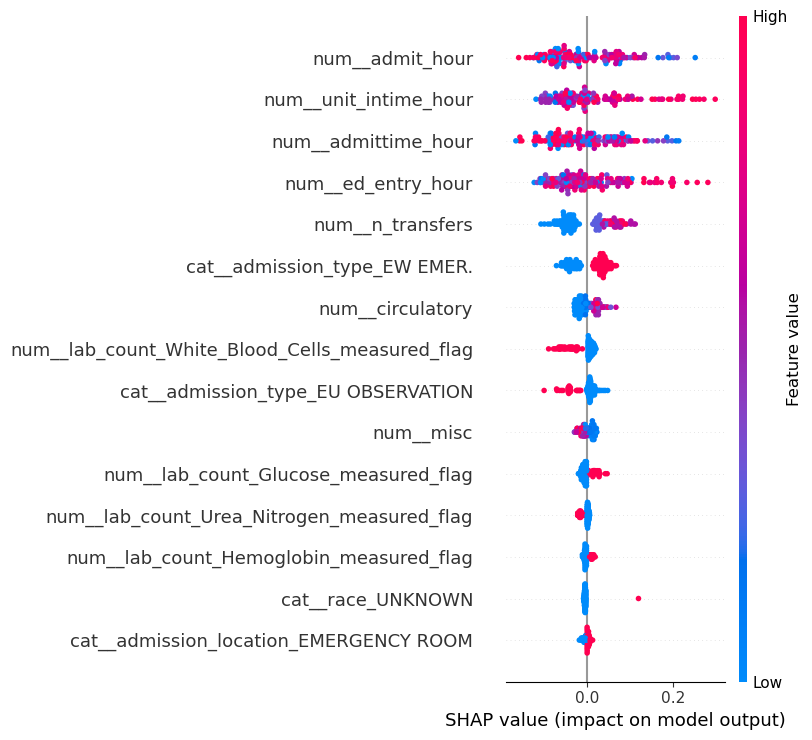


SHAP Beeswarm Plot — Class 1


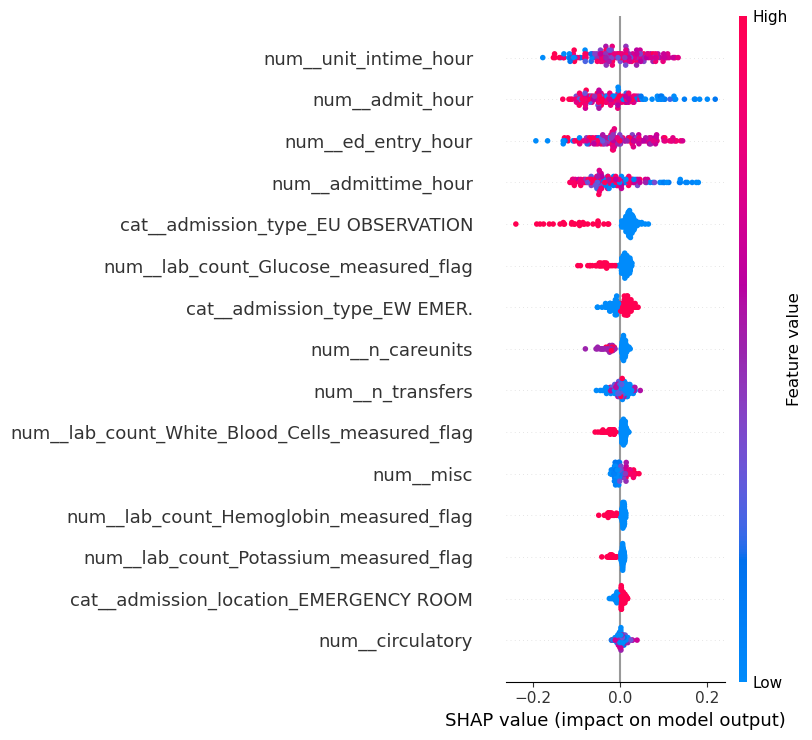


SHAP Beeswarm Plot — Class 2


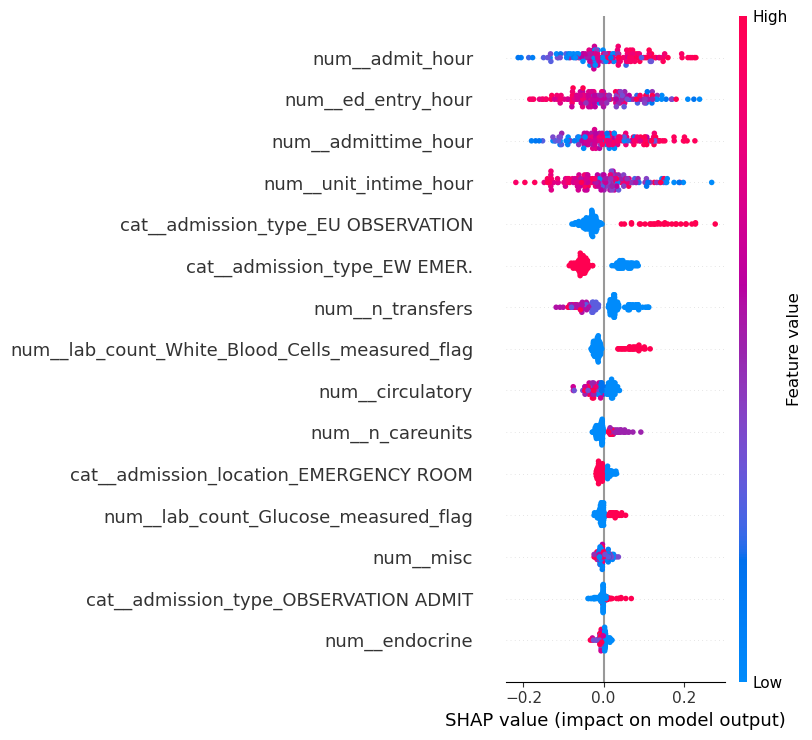

In [37]:
# ── Step 7: Beeswarm Plot — shows direction of impact per feature
for class_idx in range(len(shap_values)):
    print(f"\nSHAP Beeswarm Plot — Class {class_idx}")
    shap.summary_plot(
        shap_values[class_idx],
        X_explain,
        max_display=15,
        show=True
    )




In [38]:
# ── Step 8: Feature importance table — averaged across all 3 classes
mean_shap = np.mean(
    [np.abs(sv).mean(axis=0) for sv in shap_values], axis=0
)

shap_importance_df = pd.DataFrame({
    "feature":    feature_names,
    "mean_shap":  mean_shap
}).sort_values("mean_shap", ascending=False).reset_index(drop=True)

print("\nTop 20 features by mean |SHAP| across all classes:")
print(shap_importance_df.head(20).to_string(index=False))





Top 20 features by mean |SHAP| across all classes:
                                       feature  mean_shap
                               num__admit_hour   0.065800
                         num__unit_intime_hour   0.064204
                            num__ed_entry_hour   0.062425
                           num__admittime_hour   0.062363
            cat__admission_type_EU OBSERVATION   0.037095
                              num__n_transfers   0.035715
                  cat__admission_type_EW EMER.   0.035599
num__lab_count_White_Blood_Cells_measured_flag   0.020180
                              num__circulatory   0.015988
          num__lab_count_Glucose_measured_flag   0.013602
                              num__n_careunits   0.011834
                                     num__misc   0.010620
        cat__admission_location_EMERGENCY ROOM   0.008094
       num__lab_count_Hemoglobin_measured_flag   0.007165
        num__lab_count_Potassium_measured_flag   0.005950
         cat__admiss

<Figure size 900x700 with 0 Axes>

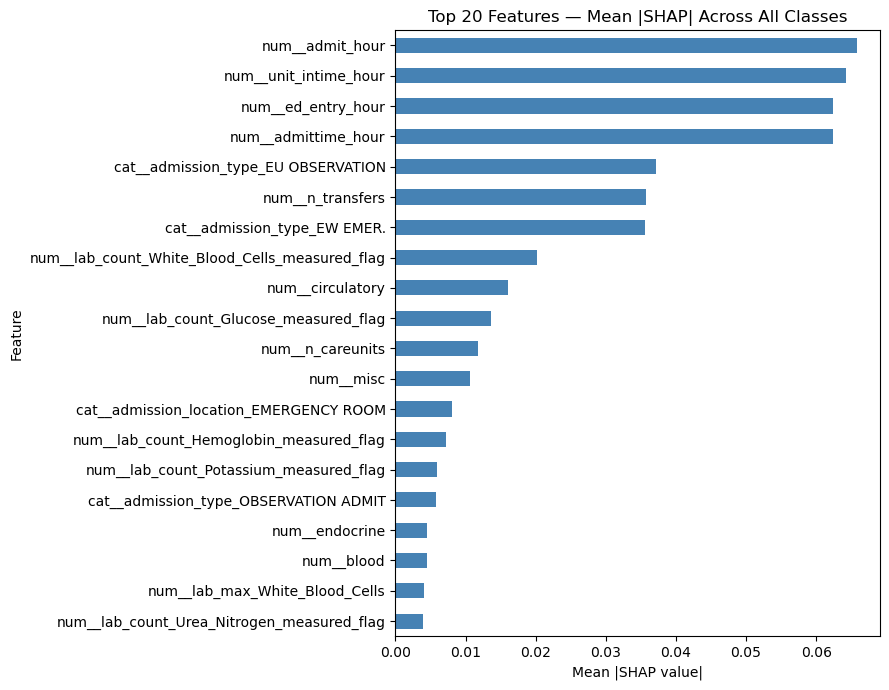

In [39]:
# ── Step 9: Horizontal bar chart of top 20
plt.figure(figsize=(9, 7))
shap_importance_df.head(20).sort_values("mean_shap").plot(
    kind="barh",
    x="feature",
    y="mean_shap",
    legend=False,
    color="steelblue",
    figsize=(9, 7)
)
plt.title("Top 20 Features — Mean |SHAP| Across All Classes")
plt.xlabel("Mean |SHAP value|")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [40]:
def end_signature():
    print("="*40)
    print("END OF NOTEBOOK — AT")
    print("="*40)

end_signature()

END OF NOTEBOOK — AT
